# 05 — O subset viral∩hit

**O que vamos olhar e por quê.** O paper Oliveira BraSNAM 2025 trabalha com **1.977 músicas** que apareceram tanto no Top 200 quanto no Viral 50 BR. Esse "subset duplo-validado" é o conjunto experimental do paper — e será também o nosso. Mas o nosso tem **1.179 músicas**, não 1.977. Esse notebook explica de onde vem essa diferença e perfila o subset que efetivamente vamos usar.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "exploration":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from music_diffusion_gnn.data.loaders import load_charts, load_songs, load_artists
from music_diffusion_gnn.data.subset import load_subset, build_subset

subset_path = ROOT / "data" / "processed" / "subset_ids.json"
if not subset_path.exists():
    print("Materializando subset_ids.json…")
    build_subset()
subset_ids = load_subset()
print(f'subset: {len(subset_ids):,} músicas')
print('exemplo de IDs:', subset_ids[:3])

subset: 1,179 músicas
exemplo de IDs: ['000xQL6tZNLJzIrtIgxqSl', '00zzSEe82JTtz68XlARnh7', '017PF4Q3l4DBUiWoXk4OWT']


## 1) De onde vem a diferença para o paper?

In [2]:
charts = load_charts()
top_ids = set(charts.loc[charts['chart'] == 'top200', 'song_id'].dropna())
viral_ids = set(charts.loc[charts['chart'] == 'viral50', 'song_id'].dropna())

comparison = pd.DataFrame({
    'fonte': ['Top 200 (única)', 'Viral 50 (única)', 'viral ∩ hit (subset)'],
    'paper Oliveira 2025': [3292, 4356, 1977],
    'nosso (carregamento atual)': [len(top_ids), len(viral_ids), len(top_ids & viral_ids)],
})
comparison['gap %'] = (
    (1 - comparison['nosso (carregamento atual)'] / comparison['paper Oliveira 2025']) * 100
).round(1)
print(comparison.to_string(index=False))

print('\nCausa da diferença:')
print('  • Viral 50 do Kaggle tem ~60% de cobertura por dia (scraper degradou em 2020+).')
print('  • Período do Kaggle termina em 2021-12; paper usa até 2022-03 (+~4%).')
print('  • Não há fonte pública completa do Viral 50.')

               fonte  paper Oliveira 2025  nosso (carregamento atual)  gap %
     Top 200 (única)                 3292                        3292    0.0
    Viral 50 (única)                 4356                        4356    0.0
viral ∩ hit (subset)                 1977                        1179   40.4

Causa da diferença:
  • Viral 50 do Kaggle tem ~60% de cobertura por dia (scraper degradou em 2020+).
  • Período do Kaggle termina em 2021-12; paper usa até 2022-03 (+~4%).
  • Não há fonte pública completa do Viral 50.


## 2) Perfil temporal do subset

Cobertura de features acústicas no subset: 1179/1179 (100.0%)


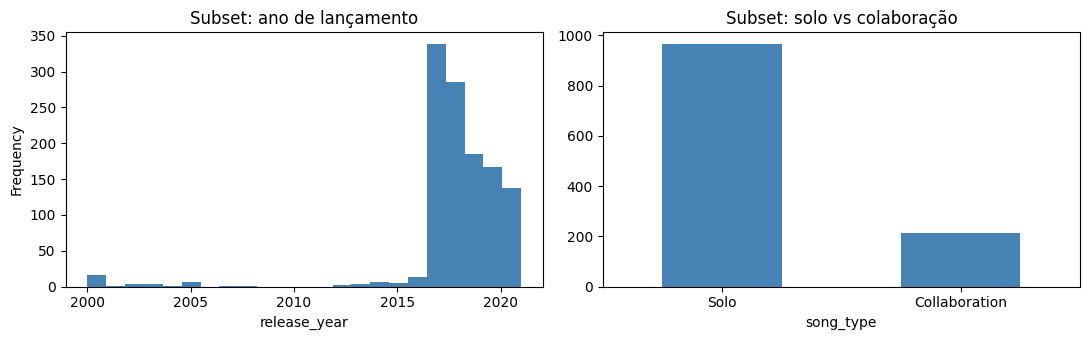

In [3]:
songs = load_songs()
songs_subset = songs[songs['song_id'].isin(subset_ids)].copy()
print(f'Cobertura de features acústicas no subset: {len(songs_subset)}/{len(subset_ids)} '
      f'({100 * len(songs_subset) / len(subset_ids):.1f}%)')

songs_subset['release_year'] = pd.to_datetime(
    songs_subset['release_date'], errors='coerce'
).dt.year

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
songs_subset['release_year'].dropna().clip(2000, 2022).plot.hist(
    bins=23, ax=axes[0], color='steelblue'
)
axes[0].set_title('Subset: ano de lançamento')
axes[0].set_xlabel('release_year')

if 'song_type' in songs_subset.columns:
    songs_subset['song_type'].value_counts().plot.bar(ax=axes[1], color='steelblue')
    axes[1].set_title('Subset: solo vs colaboração')
    axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 3) Quem está no subset (artistas e gêneros)

In [4]:
import ast

# Lista plana (artist_id, song_id)
def explode_ids(value):
    if isinstance(value, str) and value.startswith('['):
        try:
            return ast.literal_eval(value)
        except Exception:
            return []
    if isinstance(value, list):
        return value
    return [value] if pd.notna(value) else []

songs_subset['artist_ids_list'] = songs_subset['artist_id'].apply(explode_ids)
pairs = songs_subset.explode('artist_ids_list')[['song_id', 'artist_ids_list']].rename(
    columns={'artist_ids_list': 'artist_id'}
)

artists = load_artists()
id_to_name = dict(zip(artists['artist_id'], artists['name']))
pairs['artist_name'] = pairs['artist_id'].map(id_to_name)

print(f'Artistas distintos no subset: {pairs["artist_id"].nunique():,}')
print('\nTop 15 artistas por # músicas no subset:')
print(pairs.dropna(subset=['artist_name']).groupby('artist_name')
      .size().sort_values(ascending=False).head(15).to_string())

Artistas distintos no subset: 526

Top 15 artistas por # músicas no subset:
artist_name
Drake                 29
BTS                   24
Demi Lovato           22
Kendrick Lamar        20
Ed Sheeran            20
Jorge & Mateus        19
Camila Cabello        19
Gusttavo Lima         18
Marília Mendonça      18
Taylor Swift          18
Ariana Grande         17
Lana Del Rey          17
Harry Styles          17
Anitta                16
Henrique & Juliano    15


In [5]:
# Gêneros — via lookup nos artistas do subset
subset_artists = artists[artists['artist_id'].isin(pairs['artist_id'])]
all_genres = pd.Series([g for lst in subset_artists['genres_list'] for g in lst])
print(f'Gêneros distintos cobertos pelo subset: {all_genres.nunique():,}')
print('\nTop 15 gêneros (contagem por # de pares artista×gênero no subset):')
print(all_genres.value_counts().head(15).to_string())

Gêneros distintos cobertos pelo subset: 285

Top 15 gêneros (contagem por # de pares artista×gênero no subset):
pop                        97
funk carioca               57
sertanejo universitario    51
rap                        43
arrocha                    41
sertanejo                  30
dance pop                  25
pop nacional               23
trap                       22
hip hop                    20
funk paulista              17
pop dance                  17
funk mtg                   17
pop rap                    17
agronejo                   16


## Insight para o GNN

1. **O subset (~1.179 músicas) é o conjunto de treino/avaliação.** É sobre essas trajetórias que o RMSE final vai ser comparado contra SIR e wave-based.
2. **O grafo, porém, não pode incluir só essas 1.179 músicas.** Precisa cobrir também:
   - **todos os artistas** dessas músicas (mesmo que apareçam só uma vez no subset),
   - **todos os gêneros** desses artistas,
   - **vizinhos 1-hop** (artistas/gêneros conectados via colaboração ou co-ocorrência), para que o message passing tenha contexto.
3. **Cobertura acústica = 100%** — toda música do subset tem features completas. Sem necessidade de imputação.
4. **Limitação a documentar no paper:** subset 40% menor que o do paper; conclusões sobre ranking de modelos seguem comparáveis (mesmas curvas, mesmas métricas), mas valores absolutos podem deslocar.
5. **Decisão para Phase 1:** o conjunto-alvo (`music_target_ids`) e o conjunto-grafo (`music_node_ids ⊇ target ∪ vizinhança`) devem ser materializados separadamente em `data/processed/`.